In [8]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Walmart

!Question Exam June 2024!

Below are Wal-Mart's quarterly sales (expressed in billion dollars)
1. Convert the “startdate” to the datatype datetime.
2. Create the plot below.

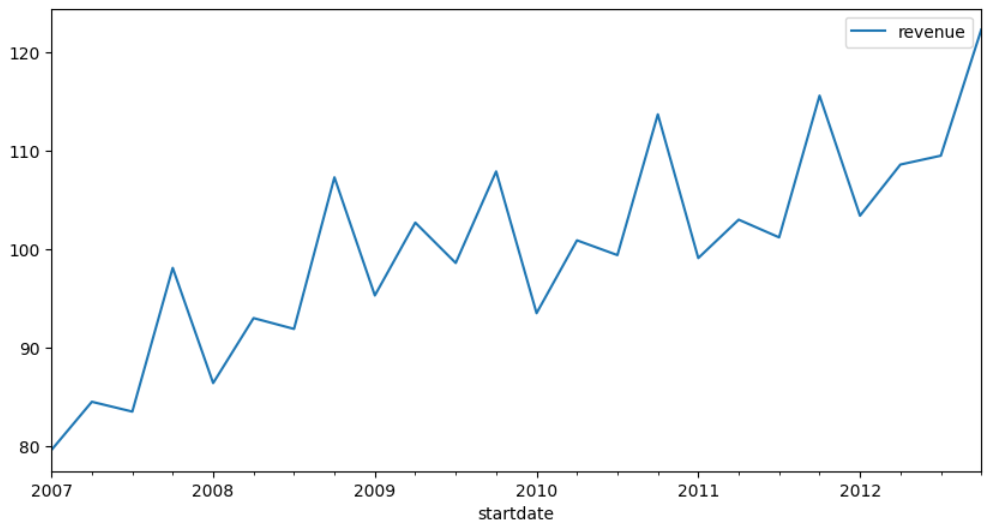

3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.
4. Make a plot including the forecast for the next accounting year.
5. In which quarter will sales exceed $150 billion for the first time? [2018-10-01]

In [9]:
dfwalmart = pd.DataFrame(data={
    'startdate': ['2007/01/01', '2007/04/01', '2007/07/01', '2007/10/01', '2008/01/01', '2008/04/01', '2008/07/01', '2008/10/01','2009/01/01', '2009/04/01', '2009/07/01', '2009/10/01','2010/01/01', '2010/04/01', '2010/07/01', '2010/10/01','2011/01/01', '2011/04/01', '2011/07/01', '2011/10/01','2012/01/01', '2012/04/01', '2012/07/01', '2012/10/01'],
    'quarter': ['2007-1','2007-2','2007-3','2007-4','2008-1','2008-2','2008-3','2008-4','2009-1','2009-2','2009-3','2009-4','2010-1','2010-2','2010-3','2010-4','2011-1','2011-2','2011-3','2011-4','2012-1','2011-2','2011-3','2011-4'],
    'revenue': [79.6,84.5,83.5,98.1,86.4,93,91.9,107.3,95.3,102.7,98.6,107.9,93.5,100.9,99.4,113.7,99.1,103,101.2,115.6,103.4,108.6,109.5,122.3]
})

dfwalmart.head()

,startdate,quarter,revenue
0,2007/01/01,2007-1,79.6
1,2007/04/01,2007-2,84.5
2,2007/07/01,2007-3,83.5
3,2007/10/01,2007-4,98.1
4,2008/01/01,2008-1,86.4


In [10]:
# 1. Convert the “startdate” to the datatype datetime.

# Walmart quarterly sales data
data = {
    'startdate': ['Q1 2015', 'Q2 2015', 'Q3 2015', 'Q4 2015',
                  'Q1 2016', 'Q2 2016', 'Q3 2016', 'Q4 2016',
                  'Q1 2017', 'Q2 2017', 'Q3 2017', 'Q4 2017',
                  'Q1 2018', 'Q2 2018', 'Q3 2018', 'Q4 2018'],
    'sales': [119.76, 116.18, 116.66, 131.63,
              122.29, 118.10, 119.45, 135.02,
              123.70, 119.35, 120.52, 138.81,
              126.75, 122.38, 123.90, 143.04]
}

df = pd.DataFrame(data)

def parse_quarter(quarter_str):
    parts = quarter_str.split()
    quarter = int(parts[0][1])
    year = int(parts[1])
    month = (quarter - 1) * 3 + 1
    return pd.Timestamp(year=year, month=month, day=1)

df['Date'] = df['startdate'].apply(parse_quarter)
df = df.set_index('Date')

print(df)

           startdate   sales
Date                        
2015-01-01   Q1 2015  119.76
2015-04-01   Q2 2015  116.18
2015-07-01   Q3 2015  116.66
2015-10-01   Q4 2015  131.63
2016-01-01   Q1 2016  122.29
2016-04-01   Q2 2016  118.10
2016-07-01   Q3 2016  119.45
2016-10-01   Q4 2016  135.02
2017-01-01   Q1 2017  123.70
2017-04-01   Q2 2017  119.35
2017-07-01   Q3 2017  120.52
2017-10-01   Q4 2017  138.81
2018-01-01   Q1 2018  126.75
2018-04-01   Q2 2018  122.38
2018-07-01   Q3 2018  123.90
2018-10-01   Q4 2018  143.04


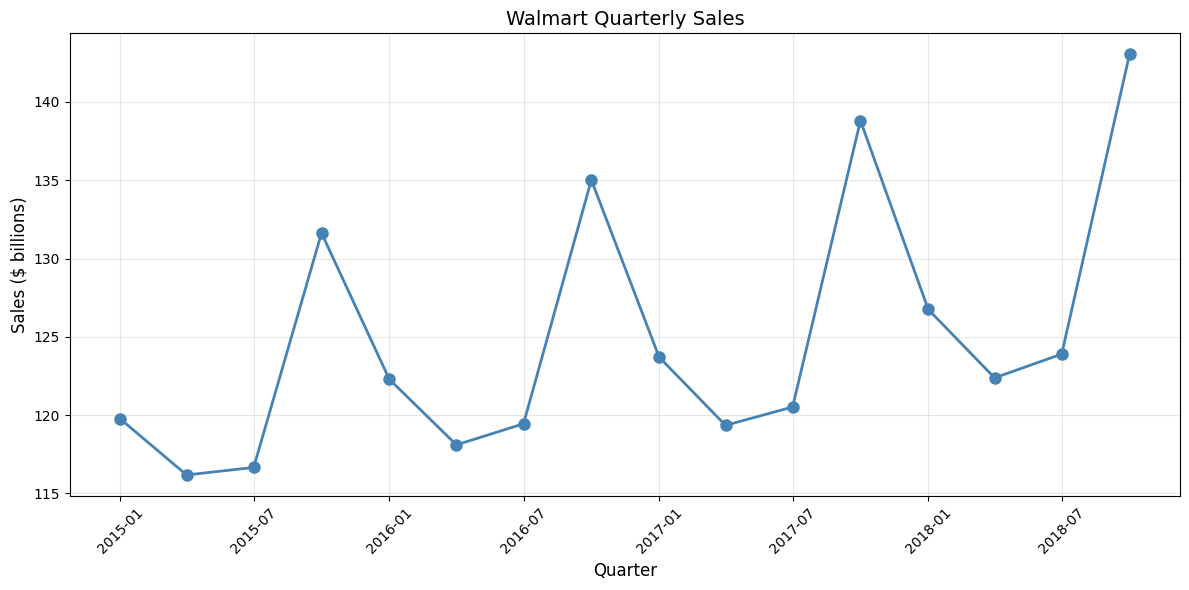

In [11]:
# 2. Create the plot below.
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'], marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title("Walmart Quarterly Sales", fontsize=14)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Sales ($ billions)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
#Observaties:

#Opwaartse trend over de tijd
#Seizoenaliteit: hogere verkopen in Q4 (feestdagen)


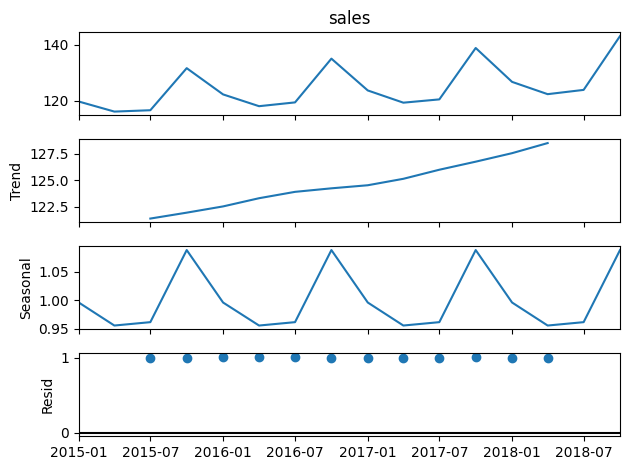

In [13]:
# 3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(df['sales'], model='multiplicative', period=4)
decomposition.plot()
plt.tight_layout()
plt.show()


In [14]:
# 4.Make a plot including the forecast for the next accounting year.
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit Triple Exponential Smoothing (Holt-Winters) with seasonality
model = ExponentialSmoothing(
    df['sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=4
)

fit = model.fit(optimized=True)

# Get fitted values
df['Fitted'] = fit.fittedvalues

print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                   16
Model:             ExponentialSmoothing   SSE                              8.900
Optimized:                         True   AIC                              6.615
Trend:                         Additive   BIC                             12.796
Seasonal:                Multiplicative   AICC                            50.615
Seasonal Periods:                     4   Date:                 Fri, 29 May 2026
Box-Cox:                          False   Time:                         09:13:32
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level              1.4901e-08                alpha                 True
smoothing_trend          

In [18]:
# 5. In which quarter will sales exceed $150 billion for the first time?
# Forecast the next 4 quarters
forecast = fit.forecast(steps=4)
forecast_values = forecast #.predicted_mean?

print("Forecast for next 4 quarters:")
print(forecast_values)

Forecast for next 4 quarters:
2019-01-01    129.585284
2019-04-01    125.209307
2019-07-01    126.373545
2019-10-01    144.245023
Freq: QS-OCT, dtype: float64


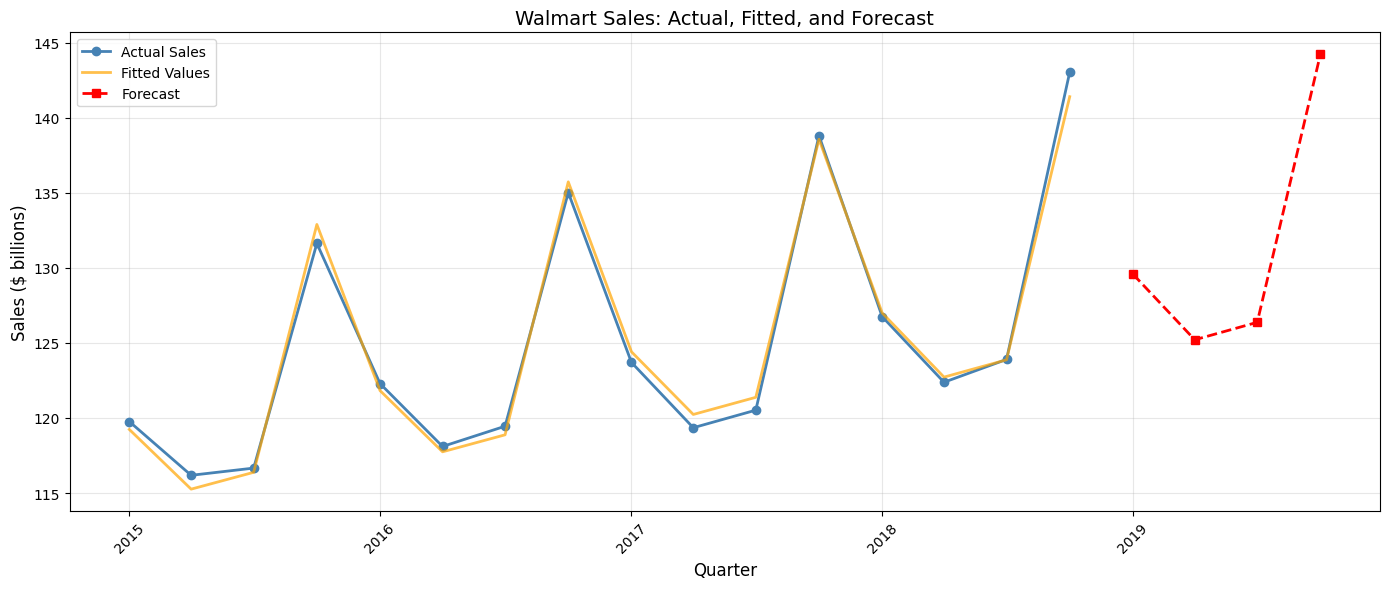

In [19]:
plt.figure(figsize=(14, 6))

# Plot actual data
plt.plot(df.index, df['sales'], marker='o', label='Actual Sales', linewidth=2, color='steelblue')

# Plot fitted values
plt.plot(df.index, df['Fitted'], label='Fitted Values', linewidth=2, color='orange', alpha=0.7)

# Plot forecast
forecast_index = pd.date_range(start=df.index[-1], periods=5, freq='QS')[1:]
plt.plot(forecast_index, forecast_values, marker='s', label='Forecast', linewidth=2,
         color='red', linestyle='--', markersize=6)

plt.title('Walmart Sales: Actual, Fitted, and Forecast', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Sales ($ billions)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Calculate model accuracy metrics
mae = mean_absolute_error(df['sales'], df['Fitted'])
rmse = np.sqrt(mean_squared_error(df['sales'], df['Fitted']))

print(f"Mean Absolute Error (MAE): ${mae:.2f}B")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}B")

Mean Absolute Error (MAE): $0.63B
Root Mean Squared Error (RMSE): $0.75B
